# 🪖 Helmet & License Plate Detection — 3-Model Comparison
### YOLOv8 vs Faster R-CNN vs SSD300 on 100 Images

**Pipeline:**
1. Download 100 labeled images (helmet + license plate) from Roboflow
2. Run all 3 models on every image
3. Compare: Precision, Recall, F1, mAP@0.5, Confidence, Speed
4. Auto-generate charts + summary table

---
## ✅ STEP 1 — Install & Import

- Install required libraries  
- Import tools for image processing and AI models  

---
## ✅ STEP 2 — Set Device

- Use GPU if available (faster)  
- Otherwise use CPU  

In [2]:
!pip install -q ultralytics roboflow opencv-python-headless matplotlib pandas torch torchvision

In [3]:
import cv2, os, glob, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torchvision.transforms as T
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
    ssd300_vgg16,            SSD300_VGG16_Weights
)
from ultralytics import YOLO
from collections import defaultdict
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


---
## ✅ STEP 3 — Download Dataset (Roboflow)

- Add your Roboflow API key  
- Connect to Roboflow account  
- Load Helmet & License Plate project  
- Download dataset in COCO format  
- Save dataset to local folder  
- Print download location  

In [4]:
from roboflow import Roboflow

# ── PASTE YOUR ROBOFLOW API KEY HERE ──────────────────────────────────────────
ROBOFLOW_API_KEY = "GE3UIQQvF8oAyqMjZ5lu"   # <-- replace this
# ──────────────────────────────────────────────────────────────────────────────

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Dataset: Helmet + License Plate, 787 images, COCO format
# Source: https://universe.roboflow.com/helmetdetection-and-numberplatedetection/helmet-detection-and-number-plate-detection-gqppa
project = rf.workspace("helmetdetection-and-numberplatedetection").project(
    "helmet-detection-and-number-plate-detection-gqppa"
)
dataset = project.version(1).download("coco", location="./helmet_plate_dataset")

print("\n✅ Dataset downloaded!")
print(f"Location: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...

✅ Dataset downloaded!
Location: c:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\src\helmet_plate_dataset


## ✅ STEP 4 — Create Test Subset & Ground Truth Preparation

* Detect available dataset split (train / valid / test)
* Load COCO annotation file
* Map image IDs to filenames
* Group annotations by image ID
* Verify available images on disk
* Filter images that contain annotations only
* Shuffle dataset randomly (fixed seed for reproducibility)
* Select 42 annotated images
* Copy selected images to working directory
* Convert bounding boxes to (x1, y1, x2, y2) format
* Store ground truth annotations in dictionary
* Print total prepared images and output path


In [5]:
import random, shutil, os, json
from collections import defaultdict

BASE       = r"c:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\src\helmet_plate_dataset"
OUTPUT_DIR = r"c:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\Comparison_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

split_used = None
for split in ['test', 'valid', 'train']:
    candidate_img_dir  = os.path.join(BASE, split)
    candidate_ann_file = os.path.join(BASE, split, '_annotations.coco.json')
    if os.path.isdir(candidate_img_dir) and os.path.exists(candidate_ann_file):
        img_dir, ann_file, split_used = candidate_img_dir, candidate_ann_file, split
        break

print(f"✅ Using split: {split_used} | img_dir: {img_dir}")

with open(ann_file) as f:
    coco = json.load(f)

id_to_file = {img['id']: img['file_name'] for img in coco['images']}
id_to_anns = defaultdict(list)
for ann in coco['annotations']:
    id_to_anns[ann['image_id']].append(ann)

actual_files = {f.lower(): os.path.join(img_dir, f) for f in os.listdir(img_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))}
print(f"   JSON images: {len(id_to_file)} | Disk images: {len(actual_files)}")

WORK_DIR = os.path.join(OUTPUT_DIR, "test_100")
os.makedirs(WORK_DIR, exist_ok=True)
image_list, gt_registry = [], {}

annotated_ids = [i for i in id_to_file if id_to_anns[i]]
random.seed(42); random.shuffle(annotated_ids)

for img_id in annotated_ids:
    if len(image_list) >= 100: break
    base_fname = os.path.basename(id_to_file[img_id])
    src = actual_files.get(base_fname.lower())
    if src is None: continue
    dst = os.path.join(WORK_DIR, base_fname)
    shutil.copy(src, dst)
    image_list.append((dst, img_id))
    gt_registry[img_id] = [[a['bbox'][0], a['bbox'][1],
                             a['bbox'][0]+a['bbox'][2], a['bbox'][1]+a['bbox'][3]]
                            for a in id_to_anns[img_id]]

print(f"\n✅ {len(image_list)} images ready in {WORK_DIR}")

✅ Using split: test | img_dir: c:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\src\helmet_plate_dataset\test
   JSON images: 42 | Disk images: 42

✅ 42 images ready in c:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\Comparison_Results\test_100


## ✅ STEP 5 — Load Models & Set Confidence Threshold

* Load custom YOLOv8 model (`best.pt`)
* Print YOLO class names
* Load pretrained Faster R-CNN (COCO weights) and set to evaluation mode
* Load pretrained SSD300 (COCO weights) and set to evaluation mode
* Move all models to the specified device (`DEVICE`)
* Set confidence threshold for predictions (`CONF = 0.4`)


In [6]:
# ── YOLOv8: your custom trained model ────────────────────────────────────────
YOLO_PATH = r'C:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\models\best.pt'
print("Loading YOLOv8...")
yolo = YOLO(YOLO_PATH)
print(f"  ✅ YOLOv8 | classes: {list(yolo.names.values())}")

# ── Faster R-CNN: pretrained on COCO ─────────────────────────────────────────
print("Loading Faster R-CNN...")
frcnn = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
frcnn.to(DEVICE).eval()
print("  ✅ Faster R-CNN ready")

# ── SSD300: pretrained on COCO ────────────────────────────────────────────────
print("Loading SSD300...")
ssd = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)
ssd.to(DEVICE).eval()
print("  ✅ SSD300 ready")

# Confidence threshold for all models
CONF = 0.4

Loading YOLOv8...
  ✅ YOLOv8 | classes: ['Plate', 'WithHelmet', 'WithoutHelmet']
Loading Faster R-CNN...
  ✅ Faster R-CNN ready
Loading SSD300...
  ✅ SSD300 ready


## ✅ STEP 6 — Define Inference Functions

* Define relevant COCO classes for our task
* Keep only target classes (`person`, `bicycle`, `car`, `motorcycle`)
* **YOLOv8 inference (`infer_yolo`)**:

  * Run model on input image
  * Extract bounding boxes and confidence scores
  * Measure inference time in milliseconds
* **Torch models inference (`infer_torch`)** for Faster R-CNN / SSD300:

  * Convert BGR image to RGB and tensor
  * Run model in evaluation mode (`no_grad`)
  * Filter boxes by confidence threshold and relevant classes
  * Measure inference time in milliseconds
* Print confirmation that inference functions are ready


In [7]:
# COCO classes relevant to our task
COCO_LABELS = ['__background__','person','bicycle','car','motorcycle','airplane',
    'bus','train','truck','boat','traffic light','fire hydrant','N/A','stop sign',
    'parking meter','bench','bird','cat','dog','horse','sheep','cow','elephant',
    'bear','zebra','giraffe','N/A','backpack','umbrella','N/A','N/A','handbag',
    'tie','suitcase','frisbee','skis','snowboard','sports ball','kite',
    'baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','N/A','wine glass','cup','fork','knife','spoon','bowl','banana',
    'apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
    'cake','chair','couch','potted plant','bed','N/A','dining table','N/A',
    'N/A','toilet','N/A','tv','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','N/A','book','clock',
    'vase','scissors','teddy bear','hair drier','toothbrush']

# Only keep these COCO classes (person=rider, car/motorcycle=vehicle with plate)
KEEP_COCO_IDS = {1, 2, 3, 4}  # person, bicycle, car, motorcycle


def infer_yolo(img_bgr):
    t0 = time.perf_counter()
    res = yolo(img_bgr, conf=CONF, verbose=False)[0]
    ms = (time.perf_counter() - t0) * 1000
    boxes, scores = [], []
    for b in res.boxes:
        boxes.append(b.xyxy[0].cpu().numpy().astype(int).tolist())
        scores.append(float(b.conf))
    return {'boxes': boxes, 'scores': scores, 'ms': ms}


def infer_torch(model, img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor  = T.ToTensor()(img_rgb).to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        preds = model([tensor])[0]
    ms = (time.perf_counter() - t0) * 1000
    boxes, scores = [], []
    for box, lbl, sc in zip(preds['boxes'].cpu().numpy(),
                             preds['labels'].cpu().numpy(),
                             preds['scores'].cpu().numpy()):
        if sc < CONF: continue
        if int(lbl) not in KEEP_COCO_IDS: continue
        boxes.append(box.astype(int).tolist())
        scores.append(float(sc))
    return {'boxes': boxes, 'scores': scores, 'ms': ms}


print("✅ Inference functions defined")

✅ Inference functions defined


## ✅ STEP 7 — Define Evaluation Metrics

* **IoU (`iou`)**: compute intersection-over-union between two bounding boxes
* **Precision, Recall, F1 (`precision_recall_f1`)**:

  * Match predicted boxes to ground truth using IoU threshold
  * Count true positives, false positives, and false negatives
  * Compute precision, recall, and F1 score
* **Average Precision (`average_precision`)**:

  * Sort predictions by confidence
  * Match predictions to ground truth boxes
  * Compute precision-recall curve
  * Apply 11-point interpolation to calculate AP
* Print confirmation that metrics functions are ready


In [8]:
def iou(a, b):
    xi1,yi1 = max(a[0],b[0]), max(a[1],b[1])
    xi2,yi2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/ua if ua > 0 else 0.0


def precision_recall_f1(pred_boxes, gt_boxes, iou_thr=0.5):
    if not pred_boxes or not gt_boxes:
        return 0.0, 0.0, 0.0
    matched = set()
    tp = fp = 0
    for pred in pred_boxes:
        best, best_i = 0, -1
        for i, gt in enumerate(gt_boxes):
            v = iou(pred, gt)
            if v > best: best, best_i = v, i
        if best >= iou_thr and best_i not in matched:
            tp += 1; matched.add(best_i)
        else:
            fp += 1
    fn = len(gt_boxes) - len(matched)
    p  = tp/(tp+fp)   if (tp+fp)>0  else 0
    r  = tp/(tp+fn)   if (tp+fn)>0  else 0
    f1 = 2*p*r/(p+r)  if (p+r)>0   else 0
    return round(p,4), round(r,4), round(f1,4)


def average_precision(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    """Compute AP for a single image using 11-point interpolation."""
    if not gt_boxes or not pred_boxes:
        return 0.0
    order  = np.argsort(pred_scores)[::-1]
    pboxes = [pred_boxes[i] for i in order]
    matched = set()
    tp_list, fp_list = [], []
    for pb in pboxes:
        best, best_i = 0, -1
        for i, gb in enumerate(gt_boxes):
            v = iou(pb, gb)
            if v > best: best, best_i = v, i
        if best >= iou_thr and best_i not in matched:
            tp_list.append(1); fp_list.append(0); matched.add(best_i)
        else:
            tp_list.append(0); fp_list.append(1)
    tp_cum = np.cumsum(tp_list)
    fp_cum = np.cumsum(fp_list)
    rec  = tp_cum / len(gt_boxes)
    prec = tp_cum / (tp_cum + fp_cum)
    # 11-point interpolation
    ap = 0
    for thr in np.linspace(0, 1, 11):
        p_at_r = prec[rec >= thr].max() if any(rec >= thr) else 0
        ap += p_at_r / 11
    return round(ap, 4)


print("✅ Metrics functions defined")

✅ Metrics functions defined


## ✅ STEP 8 — Run Models & Collect Evaluation Results

* **Initialize Models List (`MODEL_NAMES`)**:

  * Define the three detection models: YOLOv8, Faster R-CNN, SSD300

* **Prepare Storage (`records`, `ap_acc`)**:

  * Create a list to store per-image evaluation results
  * Initialize a dictionary to accumulate Average Precision (AP) for each model

* **Loop Through Dataset (`image_list`)**:

  * Load each image using OpenCV
  * Retrieve corresponding ground truth bounding boxes
  * Skip images that fail to load

* **Run Inference (`infer_yolo`, `infer_torch`)**:

  * Apply YOLOv8 model
  * Apply Faster R-CNN model
  * Apply SSD300 model

* **Evaluate Predictions**:

  * Compute **Precision, Recall, F1** using `precision_recall_f1`
  * Compute **Average Precision (AP)** using `average_precision`
  * Calculate average confidence score per model

* **Store Results Per Image (`row`)**:

  * Number of detections
  * Average confidence
  * Inference time (ms)
  * Precision, Recall, F1 score
  * Average Precision (AP)

* **Track Progress**:

  * Print progress update every 10 images with elapsed time

* **Convert to DataFrame (`df`)**:

  * Aggregate all results into a structured pandas DataFrame

* **Final Output**:

  * Print total execution time
  * Confirm completion of evaluation pipeline


In [9]:
MODEL_NAMES = ['YOLOv8', 'Faster_RCNN', 'SSD300']

# Per-image results
records = []

# For mAP accumulation
ap_acc = {m: [] for m in MODEL_NAMES}

print(f"Running 3 models × {len(image_list)} images...\n")
t_start = time.time()

for idx, (img_path, img_id) in enumerate(image_list):
    img = cv2.imread(img_path)
    if img is None: continue
    gt  = gt_registry.get(img_id, [])

    r_yolo  = infer_yolo(img)
    r_frcnn = infer_torch(frcnn, img)
    r_ssd   = infer_torch(ssd, img)

    row = {'image': os.path.basename(img_path), 'gt_count': len(gt)}

    for name, res in [('YOLOv8', r_yolo),
                      ('Faster_RCNN', r_frcnn),
                      ('SSD300', r_ssd)]:
        p, r, f1 = precision_recall_f1(res['boxes'], gt)
        ap = average_precision(res['boxes'], res['scores'], gt)
        ap_acc[name].append(ap)
        avg_conf = np.mean(res['scores']) if res['scores'] else 0.0

        row[f'{name}_det']      = len(res['boxes'])
        row[f'{name}_conf']     = round(avg_conf, 3)
        row[f'{name}_ms']       = round(res['ms'], 1)
        row[f'{name}_prec']     = p
        row[f'{name}_rec']      = r
        row[f'{name}_f1']       = f1
        row[f'{name}_ap']       = ap

    records.append(row)

    if (idx+1) % 10 == 0:
        elapsed = time.time() - t_start
        print(f"  {idx+1}/100 images done | {elapsed:.0f}s elapsed")

df = pd.DataFrame(records)
print(f"\n✅ Done in {time.time()-t_start:.1f}s")

Running 3 models × 42 images...

  10/100 images done | 25s elapsed
  20/100 images done | 48s elapsed
  30/100 images done | 71s elapsed
  40/100 images done | 93s elapsed

✅ Done in 97.9s


## ✅ STEP 9 — Summarize & Save Evaluation Results

* **Check for Empty Results (`df.empty`)**:

  * If no images were processed, print a warning and stop (likely an issue from Step 4).

* **Compute Per-Model Summary (`summary`)**:

  * Loop over `MODEL_NAMES` and calculate averages for each model:

    * **Avg Detections** — mean number of predicted boxes per image
    * **Avg Confidence** — mean confidence score of predictions
    * **Avg Time (ms)** — mean inference time per image
    * **FPS** — frames per second computed as `1000 / Avg Time`
    * **Precision, Recall, F1 Score** — averaged over all images
    * **mAP@0.5** — mean Average Precision at IoU 0.5

* **Create Summary DataFrame (`summary_df`)**:

  * Set the model names as the index for easier reading

* **Print Summary Table Nicely**:

  * Add separators for readability
  * Display per-model metrics for 100 images

* **Save Results to CSV**:

  * Save `df` (per-image results) to `per_image_results.csv`
  * Save `summary_df` (aggregated metrics) to `summary.csv`
  * Print confirmation of saved files and output directory


In [ ]:
summary = []
if df.empty:
    print("❌ df is empty — image_list was 0. Fix Step 4 first.")
else:
    for name in MODEL_NAMES:
        summary.append({
            'Model':           name.replace('_', ' '),
        'Avg Detections':  round(df[f'{name}_det'].mean(),  2),
        'Avg Confidence':  round(df[f'{name}_conf'].mean(), 3),
        'Avg Time (ms)':   round(df[f'{name}_ms'].mean(),   1),
        'FPS':             round(1000/df[f'{name}_ms'].mean(), 1),
        'Precision':       round(df[f'{name}_prec'].mean(), 3),
        'Recall':          round(df[f'{name}_rec'].mean(),  3),
        'F1 Score':        round(df[f'{name}_f1'].mean(),   3),
        'mAP@0.5':         round(np.mean(ap_acc[name]),     3),
    })

summary_df = pd.DataFrame(summary).set_index('Model')

# Print nicely
print("=" * 75)
print("          MODEL COMPARISON SUMMARY — 42 IMAGES")
print("=" * 75)
print(summary_df.to_string())
print("=" * 75)

# Save
df.to_csv(os.path.join(OUTPUT_DIR, 'per_image_results.csv'), index=False)
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'summary.csv'))
print(f"\n💾 CSVs saved to {OUTPUT_DIR}")

          MODEL COMPARISON SUMMARY — 100 IMAGES
             Avg Detections  Avg Confidence  Avg Time (ms)  FPS  Precision  Recall  F1 Score  mAP@0.5
Model                                                                                                
YOLOv8                 0.74           0.479          199.4  5.0      0.571   0.117     0.188    0.143
Faster RCNN           13.45           0.794         1700.2  0.6      0.258   0.219     0.208    0.202
SSD300                 5.55           0.710          392.1  2.6      0.394   0.166     0.194    0.157

💾 CSVs saved to c:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\Comparison_Results


## ✅ STEP 10 — Visualize Model Comparison

* **Setup Plot (`matplotlib`)**:

  * Create a 2×4 subplot grid with size `(22, 10)`
  * Set a main title: *“3-Model Comparison on 100 Helmet & License Plate Images”*

* **Define Colors and Metrics**:

  * Colors: green, red, orange for the three models
  * Metrics to visualize: `mAP@0.5`, `Precision`, `Recall`, `F1 Score`, `Avg Confidence`, `Avg Time (ms)`, `FPS`

* **Plot Individual Metric Bars**:

  * Loop through each metric and draw a bar chart
  * Set chart titles, axis labels, and limits (0–1 for percentages)
  * Annotate bars with actual values on top
  * Remove top and right spines for cleaner look

* **Radar-Style Quick Summary Table**:

  * Use the 8th subplot for a table showing `mAP@0.5`, `F1 Score`, and `FPS` per model
  * Format table with centered text, scaled font, and title

* **Finalize Layout & Save**:

  * Apply `tight_layout()` for spacing
  * Save figure as `comparison_charts.png` in `OUTPUT_DIR`
  * Print confirmation of saved chart and display the plot


💾 Charts saved: c:\Users\faris\Documents\GitHub\ai-fun-2026\AI-Project\Comparison_Results\comparison_charts.png


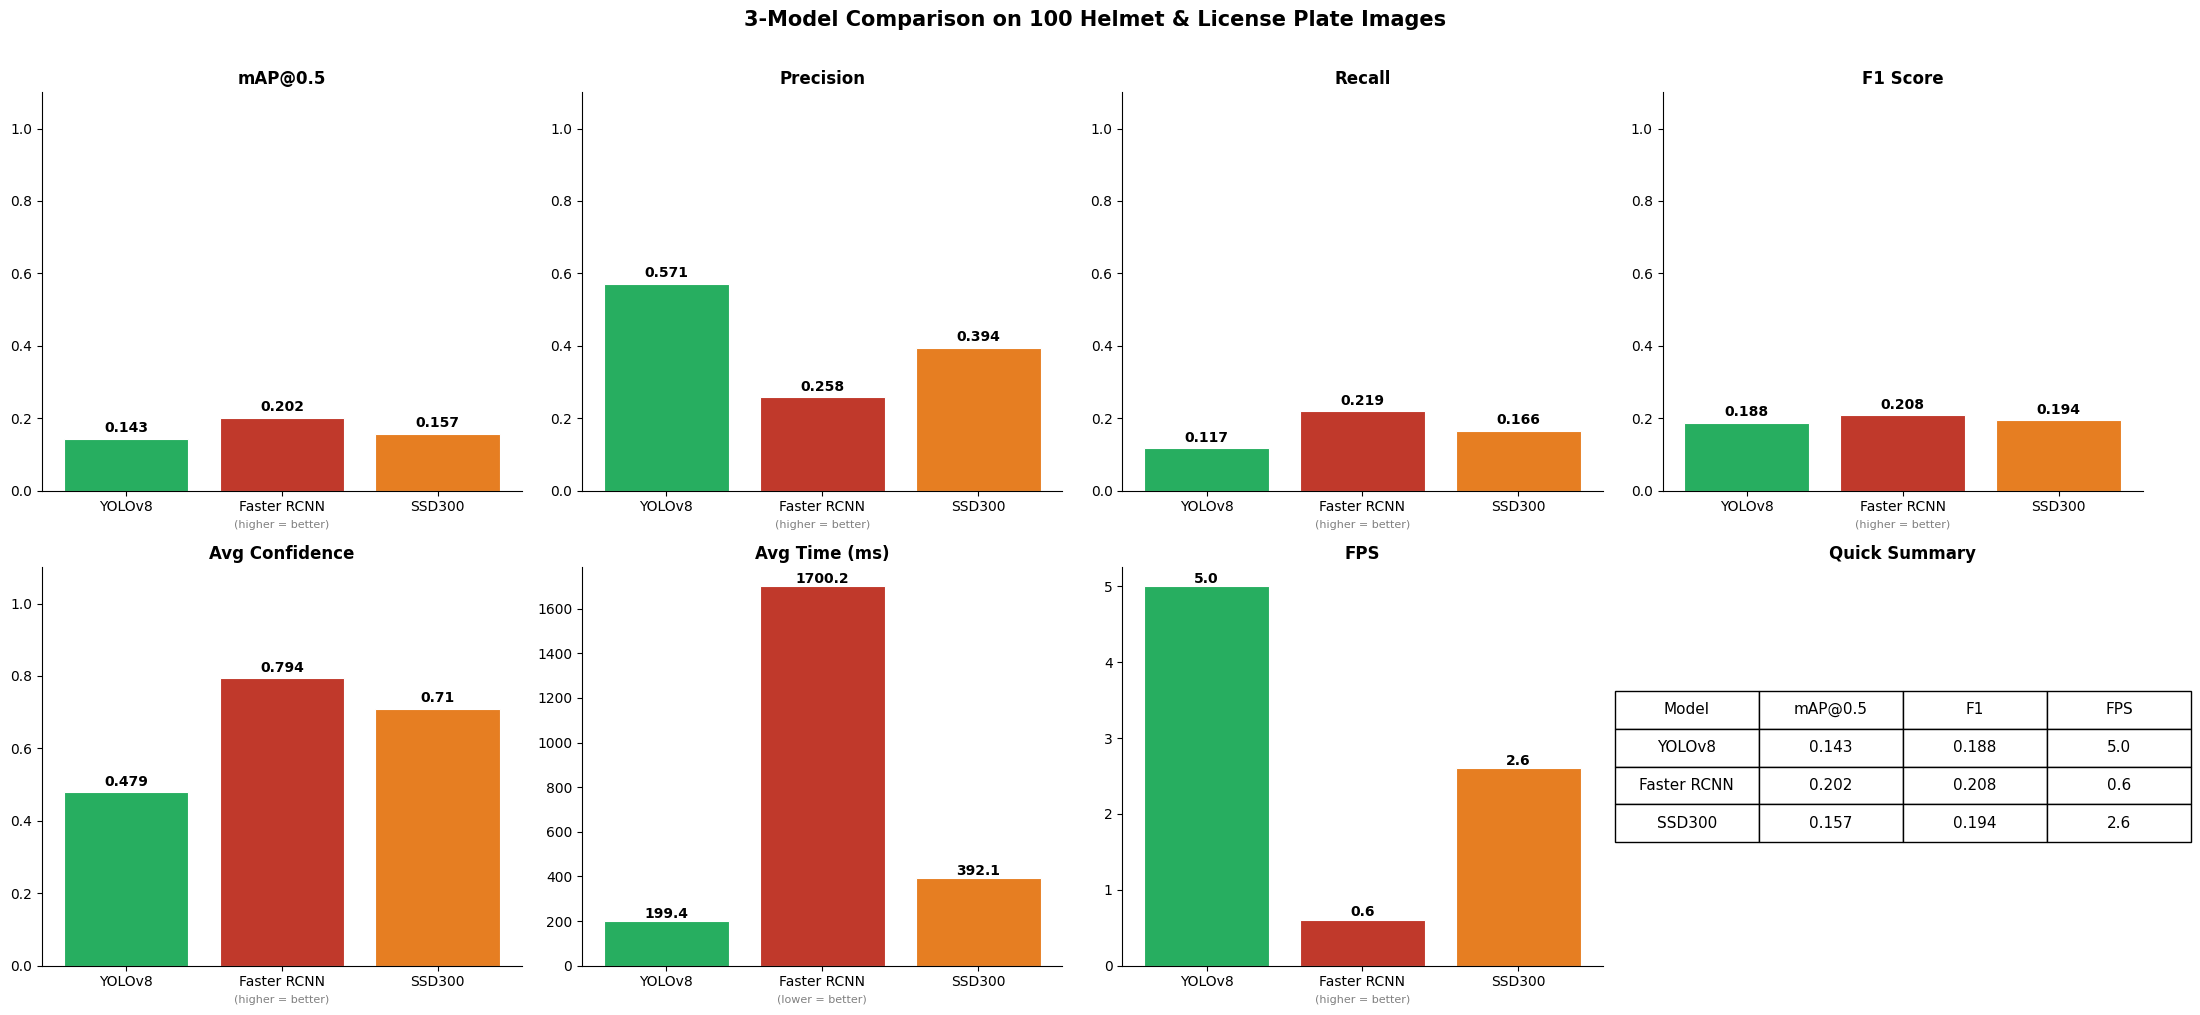

In [ ]:
models  = summary_df.index.tolist()
colors  = ['#27ae60', '#c0392b', '#e67e22']   # green / red / orange
metrics = ['mAP@0.5', 'Precision', 'Recall', 'F1 Score',
           'Avg Confidence', 'Avg Time (ms)', 'FPS']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('3-Model Comparison on 42 Helmet & License Plate Images',
             fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, metric in enumerate(metrics):
    vals = summary_df[metric].values
    bars = axes[i].bar(models, vals, color=colors, edgecolor='white', linewidth=0.8)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    note = '(higher = better)' if metric != 'Avg Time (ms)' else '(lower = better)'
    axes[i].set_xlabel(note, fontsize=8, color='gray')
    if metric not in ('Avg Time (ms)', 'FPS', 'Avg Detections'):
        axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01, f'{val}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# 8th subplot: radar-style score table
axes[7].axis('off')
tbl_data = summary_df[['mAP@0.5','F1 Score','FPS']].reset_index().values.tolist()
tbl = axes[7].table(
    cellText=tbl_data,
    colLabels=['Model', 'mAP@0.5', 'F1', 'FPS'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2)
axes[7].set_title('Quick Summary', fontsize=12, fontweight='bold')

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'comparison_charts.png')
plt.savefig(chart_path, dpi=130, bbox_inches='tight')
print(f"💾 Charts saved: {chart_path}")
plt.show()

## ✅ STEP 11 — Visualize Sample Detections

* **Draw Bounding Boxes (`draw_boxes`)**:

  * Copy the input image to avoid modifying the original
  * Draw rectangles for each bounding box using the given color
  * Add a label at the top-left corner with model or GT name

* **Show Sample Inference (`show_sample`)**:

  * Load the image and retrieve its ground truth boxes
  * Run inference for YOLOv8, Faster R-CNN, and SSD300
  * Generate panels for:

    * Ground Truth (cyan)
    * YOLOv8 (green)
    * Faster R-CNN (blue)
    * SSD300 (orange)
  * Convert BGR to RGB for proper matplotlib display

* **Plot Panels Side-by-Side**:

  * 1×4 subplot layout with titles for each panel
  * Display the original image filename as the main title
  * Hide axes for clean visualization

* **Save and Display**:

  * Optionally save visualization to `OUTPUT_DIR` with filename prefix `vis_`
  * Display the figure

* **Random Samples**:

  * Select 5 random images from `image_list`
  * Call `show_sample` to visualize detections and ground truth for each

This step allows you to **quickly inspect how each model performs** on real images, highlighting correct detections and mistakes.


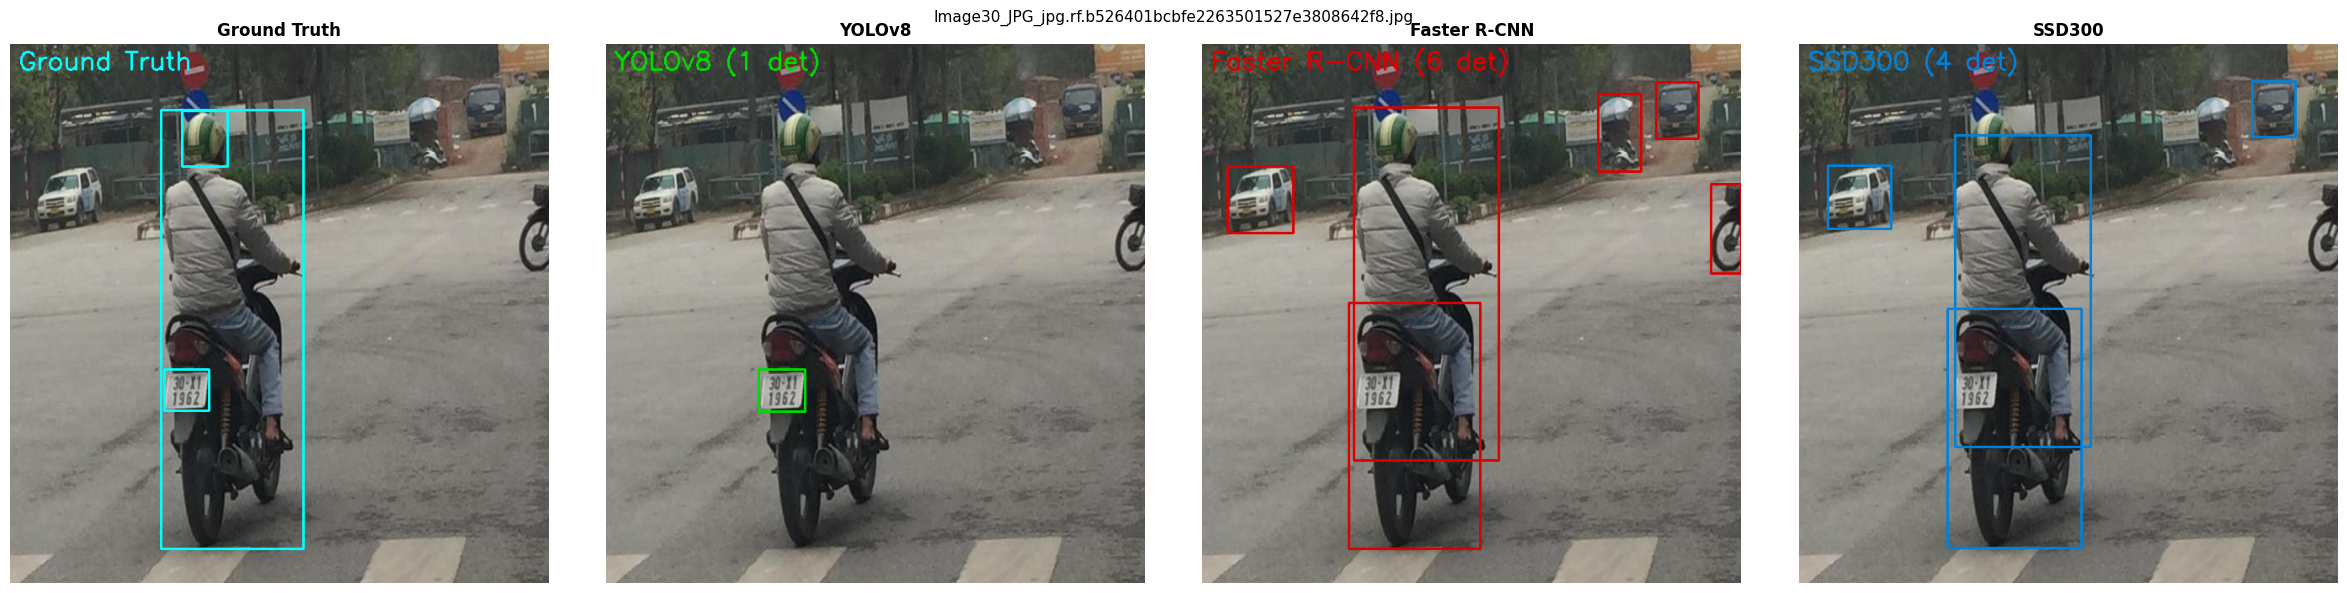

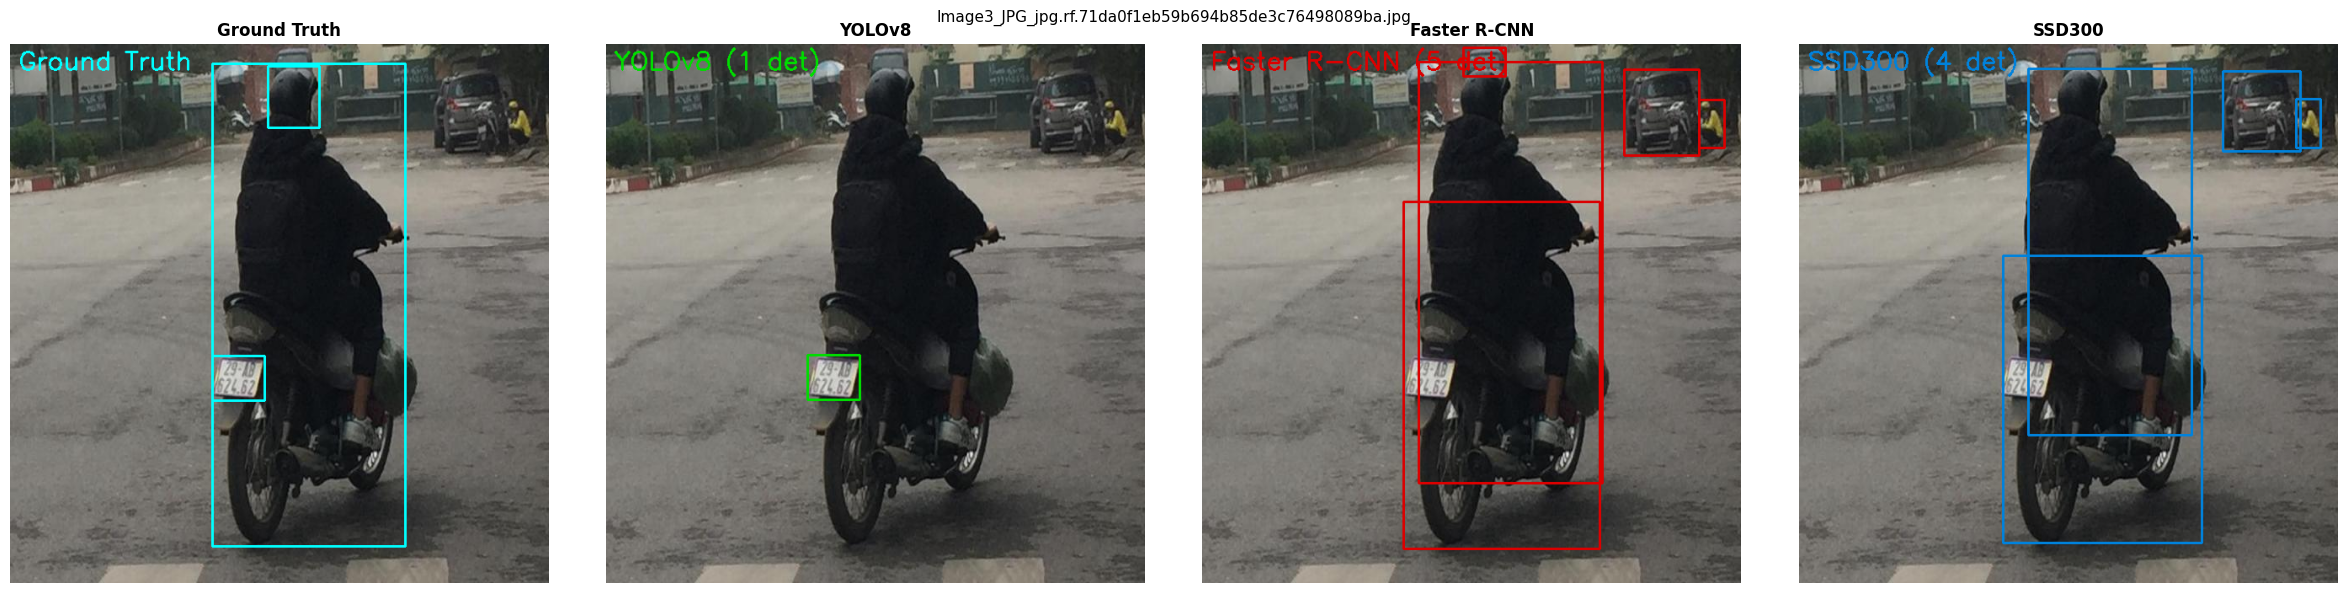

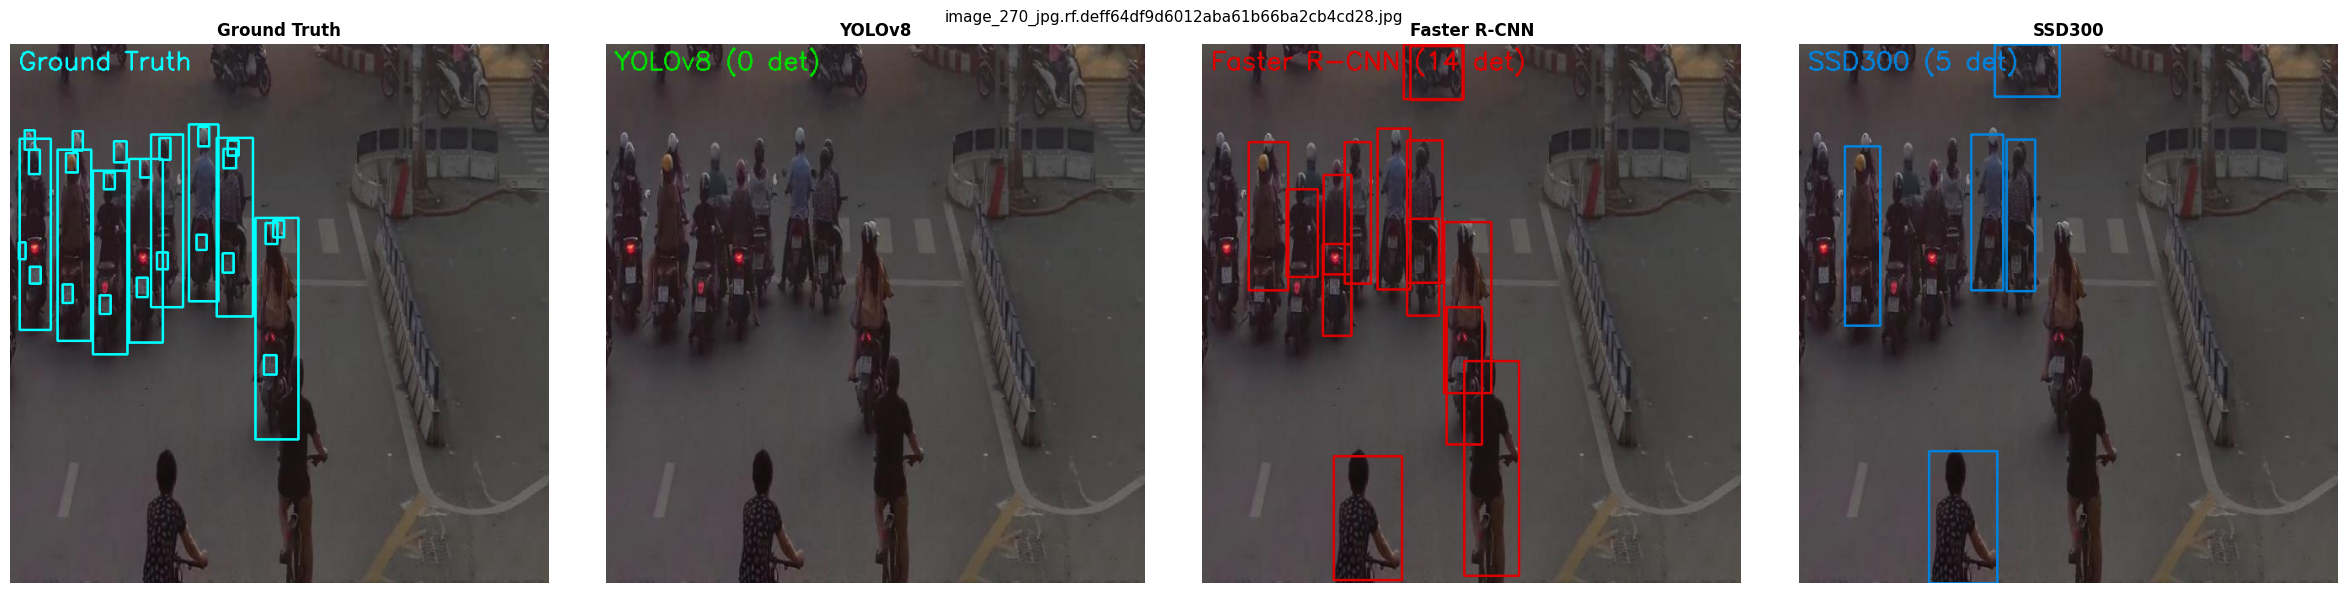

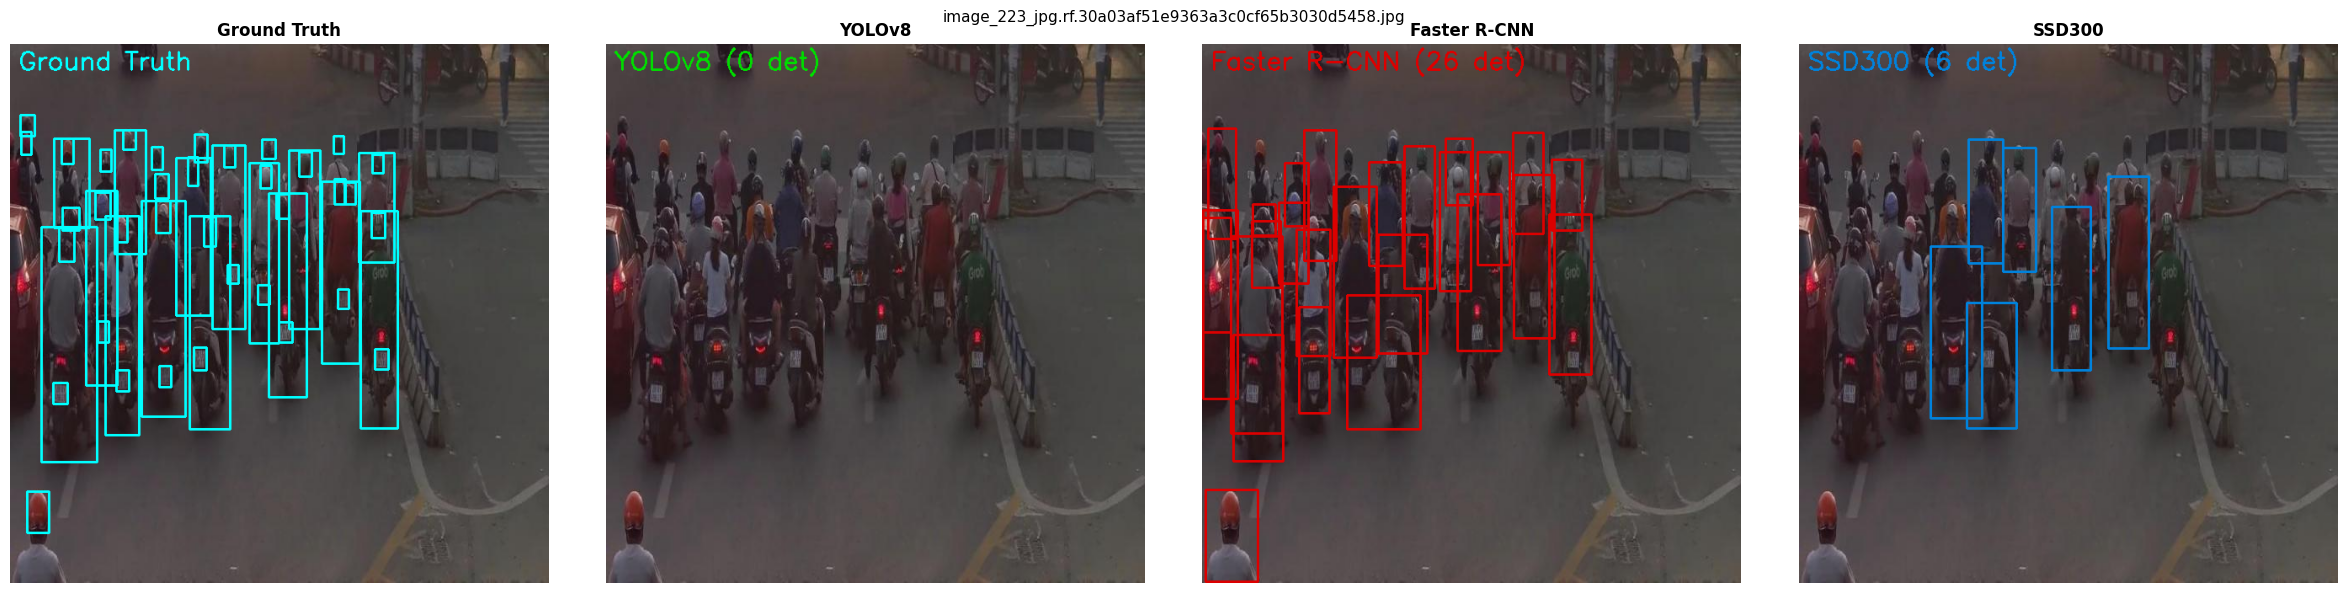

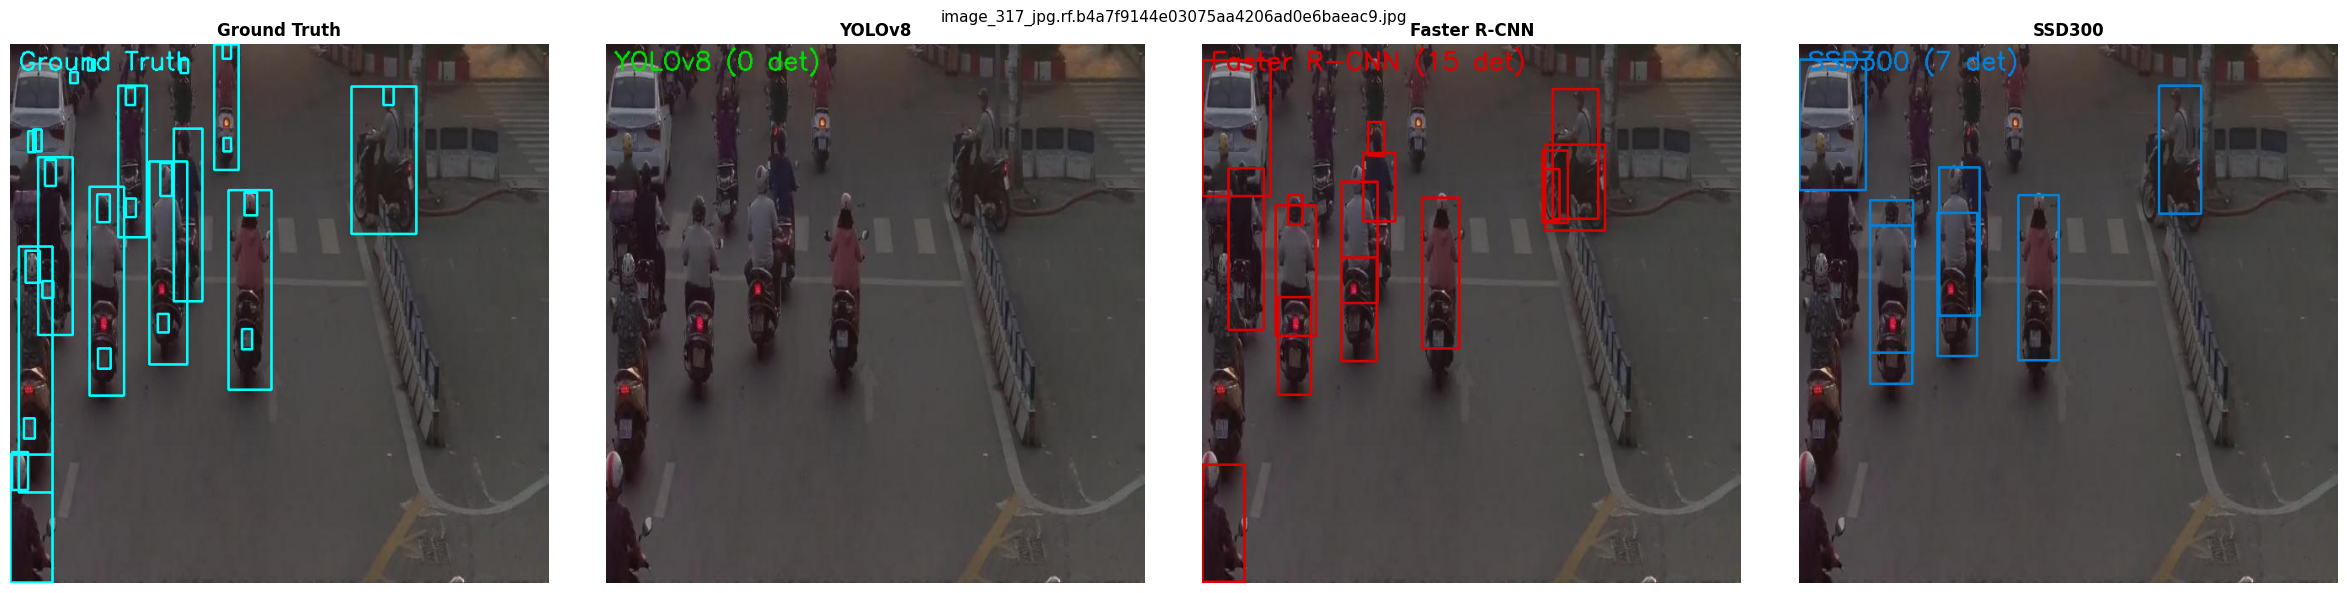

In [12]:
def draw_boxes(img, boxes, color, label):
    out = img.copy()
    for b in boxes:
        # Cast to int — OpenCV requires integer pixel coordinates
        cv2.rectangle(out, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), color, 2)
    cv2.putText(out, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    return out


def show_sample(img_path, img_id, save=True):
    img = cv2.imread(img_path)
    gt  = gt_registry.get(img_id, [])

    r_y = infer_yolo(img)
    r_f = infer_torch(frcnn, img)
    r_s = infer_torch(ssd, img)

    panels = [
        draw_boxes(img, gt,           (255, 255, 0), 'Ground Truth'),
        draw_boxes(img, r_y['boxes'], (0, 220, 0),   f"YOLOv8 ({len(r_y['boxes'])} det)"),
        draw_boxes(img, r_f['boxes'], (0, 0, 220),   f"Faster R-CNN ({len(r_f['boxes'])} det)"),
        draw_boxes(img, r_s['boxes'], (220, 130, 0), f"SSD300 ({len(r_s['boxes'])} det)"),
    ]
    panels_rgb = [cv2.cvtColor(p, cv2.COLOR_BGR2RGB) for p in panels]

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    titles = ['Ground Truth', 'YOLOv8', 'Faster R-CNN', 'SSD300']
    for ax, panel, title in zip(axes, panels_rgb, titles):
        ax.imshow(panel); ax.set_title(title, fontsize=12, fontweight='bold'); ax.axis('off')
    plt.suptitle(os.path.basename(img_path), fontsize=11)
    plt.tight_layout()
    if save:
        out_path = os.path.join(OUTPUT_DIR, f"vis_{os.path.basename(img_path)}")
        plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()


# Show 5 random sample images
sample_indices = random.sample(range(len(image_list)), 5)
for i in sample_indices:
    show_sample(*image_list[i])

## ✅ STEP 12 — Plot F1 Score Trend Across Images

* **Setup Line Plot**:

  * Create a figure `(18, 5)`
  * Use image index as the x-axis (`range(len(df))`)

* **Plot Per-Image F1 Scores**:

  * Draw a line for each model’s F1 score:

    * YOLOv8 — green
    * Faster R-CNN — red
    * SSD300 — orange
  * Set line width and transparency (`alpha=0.8`)

* **Add Rolling Average (Dashed Lines)**:

  * Compute 10-image rolling mean for each model
  * Overlay with a darker color and dashed style
  * Highlights short-term performance trends

* **Format Plot**:

  * Title: `"F1 Score per Image — All 100 Images (dashed = 10-image rolling average)"`
  * Label axes: `Image Index` and `F1 Score`
  * Limit y-axis to 0–1.05
  * Add legend and remove top/right spines for a clean look

* **Save and Display**:

  * Save figure as `f1_per_image.png` in `OUTPUT_DIR`
  * Print confirmation message

This chart helps you **visualize model consistency** across all images and detect any anomalies or unstable predictions.


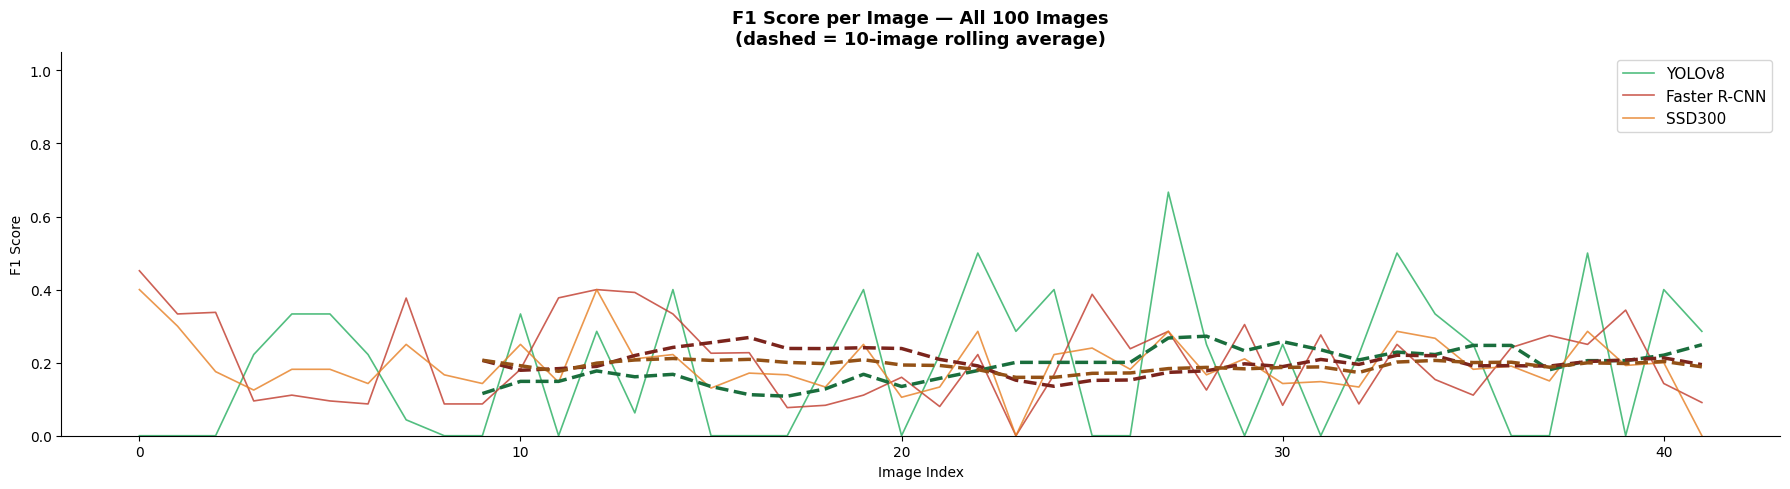

💾 F1 trend chart saved


In [13]:
fig, ax = plt.subplots(figsize=(18, 5))
x = range(len(df))
ax.plot(x, df['YOLOv8_f1'],     color='#27ae60', linewidth=1.2, label='YOLOv8',       alpha=0.8)
ax.plot(x, df['Faster_RCNN_f1'],color='#c0392b', linewidth=1.2, label='Faster R-CNN', alpha=0.8)
ax.plot(x, df['SSD300_f1'],     color='#e67e22', linewidth=1.2, label='SSD300',       alpha=0.8)

# Rolling average
for col, color in [('YOLOv8_f1','#1a6e3d'),
                    ('Faster_RCNN_f1','#7b241c'),
                    ('SSD300_f1','#935116')]:
    ax.plot(x, df[col].rolling(10).mean(), color=color, linewidth=2.5, linestyle='--')

ax.set_title('F1 Score per Image — All 100 Images\n(dashed = 10-image rolling average)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Image Index'); ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05); ax.legend(fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'f1_per_image.png'), dpi=120)
plt.show()
print("💾 F1 trend chart saved")

---
## 📝 Results Interpretation Guide

| Metric | What it tells you |
|--------|-----------------------|
| **mAP@0.5** | Overall detection quality — boxes must overlap GT by ≥50% IoU to count as correct. The higher the better. |
| **Precision** | Of all boxes the model drew, how many were correct? High precision = few false alarms. |
| **Recall** | Of all real objects in the image, how many did the model find? High recall = misses few objects. |
| **F1 Score** | Harmonic mean of Precision & Recall — single balanced accuracy score. |
| **Avg Confidence** | How certain the model is about its detections. |
| **FPS** | Frames per second inference speed. Higher = faster. |

### Expected pattern
- **YOLOv8** will likely win on all accuracy metrics because it was **fine-tuned** on your exact helmet/plate data.
- **Faster R-CNN** will be most accurate among pretrained models but slowest.
- **SSD300** will be fastest of the two pretrained models but less accurate.

> For your report: if you fine-tune Faster R-CNN and SSD on the same dataset, the comparison becomes fully fair.